In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import itertools
import copy
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision
from torchvision import transforms

# 防止内核挂掉
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# Angular Spectrum Propagation (phase & amplitude)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using Device: ',device)

Using Device:  cuda


### ***Loading and Viewing Dataset***

Using classes: ['fundamental', 'first_order', 'second_order', 'third_order', 'forth_order']
Classes: ['0_fundamental', '1_first_order', '2_second_order', '3_third_order', '4_fourth_order']
train classes: {'0_fundamental': 0, '1_first_order': 1, '2_second_order': 2, '3_third_order': 3, '4_fourth_order': 4}
val classes: {'0_fundamental': 0, '1_first_order': 1, '2_second_order': 2, '3_third_order': 3, '4_fourth_order': 4}
batch_number [40/120]
classes of the first batch: [0 1 2 3 4], number of classes: 5


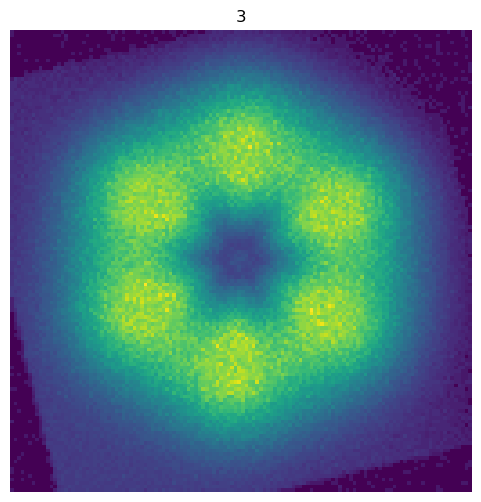

batch_number [80/120]
classes of the first batch: [0 1 2 3 4], number of classes: 5


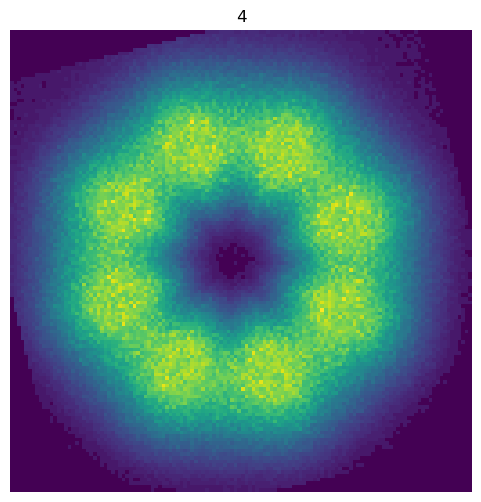

batch_number [120/120]
classes of the first batch: [0 1 2 3 4], number of classes: 5


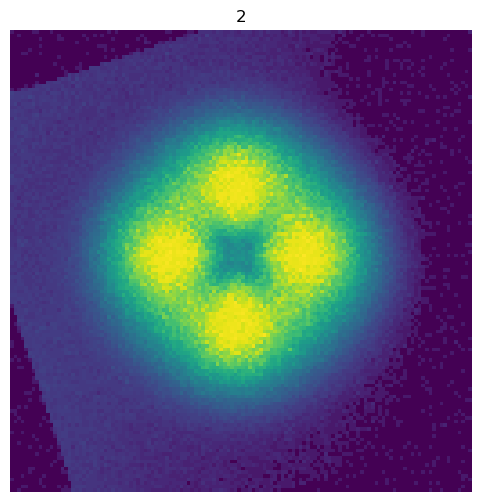

In [3]:
BATCH_SIZE = 200
IMG_SIZE = 128          # 合成数据就是 128x128
N_pixels = 128
PADDING = 0             # 已经是 128x128，不需要 pad

# 数据预处理并加载（灰度）
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])
# ====== AFTER ======
# 4 类数据集不需要 remap
train_dataset = torchvision.datasets.ImageFolder("./data/vcsel_near_synth/train",
                                                 transform=transform)
val_dataset = torchvision.datasets.ImageFolder("./data/vcsel_near_synth/val",
                                               transform=transform)

# 更新类别数与类名（5 类）
num_classes = 5
class_names = ['fundamental', 'first_order', 'second_order', 'third_order','forth_order']
print("Using classes:", class_names)

# 使用 ImageFolder 真实类别名
print("Classes:", train_dataset.classes)
print("train classes:", train_dataset.class_to_idx)
print("val classes:", val_dataset.class_to_idx)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 定义一个绘图函数
def image_plot(image, label):
#     cmap='RdBu'
    fig, ax = plt.subplots()
    ax.imshow(np.round(image.cpu().numpy(), 5)) # 显示图片每个像素点的振幅
    ax.axis('off')
    ax.set_title(label.cpu().numpy())
#     fig.colorbar(plt.cm.ScalarMappable(cmap=cmap))
    plt.show()

plt.rcParams["figure.figsize"] = (20, 6)
for i, (images, labels) in enumerate(train_dataloader):
    images = images.to(device)
    images_E = torch.sqrt(torch.squeeze(images))
    labels = labels.to(device)

    # 每100个批次绘制第一张图片
    if (i + 1) % 40 == 0:
        classes = torch.unique(labels).cpu().numpy()
        classes_num = len(classes)
        print('batch_number [{}/{}]'.format(i + 1, len(train_dataloader)))
        print('classes of the first batch: {}, number of classes: {}'.format(classes, classes_num))
        image_plot(images_E[0], labels[0])

In [4]:
images_E.shape

torch.Size([200, 128, 128])

### ***Diffractive Layer***

In [5]:
class Diffractive_Layer(torch.nn.Module):
    # 模型初始化（构造实例），默认实参波长为830e-9，网格总数50，网格大小2e-6，z方向传播0.002。
    def __init__(self, λ = 830e-9, N_pixels = 128, pixel_size = 2e-6, distance = torch.tensor([0.005])):
        super(Diffractive_Layer, self).__init__() # 初始化父类
        
        # 以1/d为单位频率，得到一系列频率分量[0, 1, 2, ···, N_pixels/2-1,-N_pixels/2, ···, -1]/(N_pixels*d)。
        fx = np.fft.fftshift(np.fft.fftfreq(N_pixels, d = pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(N_pixels, d = pixel_size))
        fxx, fyy = np.meshgrid(fx, fy) # 拉网格，每个网格坐标点为空间频率各分量。

        argument = (2 * np.pi)**2 * ((1. / λ) ** 2 - fxx ** 2 - fyy ** 2)

        # 计算传播场或倏逝场的模式kz，传播场kz为实数，倏逝场kz为复数
        tmp = np.sqrt(np.abs(argument))
        self.distance = distance.to(device)
        self.kz = torch.tensor(np.where(argument >= 0, tmp, 1j*tmp)).to(device)

    def forward(self, E):
        # 定义单个衍射层内的前向传播
        fft_c = torch.fft.fft2(E) # 对电场E进行二维傅里叶变换
        c = torch.fft.fftshift(fft_c).to(device) # 将零频移至张量中心
        phase = torch.exp(1j * self.kz * self.distance).to(device)
        angular_spectrum = torch.fft.ifft2(torch.fft.ifftshift(c * phase)) # 卷积后逆变换得到响应的角谱
        return angular_spectrum

### ***Propagation Layer***

In [6]:
class Propagation_Layer(torch.nn.Module):
    # 与上面衍射层大致相同，区别在于传输层是最后一个衍射层到探测器层间的部分，中间可以自定义加额外的器件。
    def __init__(self, λ = 830e-9, N_pixels = 128, pixel_size = 2e-6, distance = torch.tensor([0.001])):
        super(Propagation_Layer, self).__init__() # 初始化父类
        
        # 以1/d为单位频率，得到一系列频率分量[0, 1, 2, ···, N_pixels/2-1,-N_pixels/2, ···, -1]/(N_pixels*d)。
        fx = np.fft.fftshift(np.fft.fftfreq(N_pixels, d = pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(N_pixels, d = pixel_size))
        fxx, fyy = np.meshgrid(fx, fy) # 拉网格，每个网格坐标点为空间频率各分量。

        argument = (2 * np.pi)**2 * ((1. / λ) ** 2 - fxx ** 2 - fyy ** 2)

        # 计算传播场或倏逝场的模式kz，传播场kz为实数，倏逝场kz为复数
        tmp = np.sqrt(np.abs(argument))
        self.distance = distance.to(device)
        self.kz = torch.tensor(np.where(argument >= 0, tmp, 1j*tmp)).to(device)

    def forward(self, E):
        # 定义单个衍射层内的前向传播
        fft_c = torch.fft.fft2(E) # 对电场E进行二维傅里叶变换
        c = torch.fft.fftshift(fft_c) # 将零频移至张量中心
        phase = torch.exp(1j * self.kz * self.distance).to(device)
        angular_spectrum = torch.fft.ifft2(torch.fft.ifftshift(c * phase)) # 卷积后逆变换得到响应的角谱
        return angular_spectrum

In [7]:
def propagation_along_z(initial_field, wl, N_pixels, pixel_size, z_step, number_of_z_steps):
    diffraction_step = Diffractive_Layer(distance=torch.tensor(z_step), λ=wl, N_pixels=N_pixels, pixel_size=pixel_size)
    z_ind = np.arange(0, number_of_z_steps)
    full_cross_section = torch.zeros((len(z_ind), N_pixels, N_pixels), dtype=torch.complex64)
    full_cross_section[0] = initial_field.detach().clone()
    with torch.no_grad():
        for ind in z_ind[1:]:
            full_cross_section[ind] = diffraction_step(full_cross_section[ind-1])
        return full_cross_section

DISCRETIZATION_STEP = 2.0e-6 # 网格大小
N_pixels = 128 # xy平面边长的元素点数量
z_step = 1e-5 # z方向步长
number_of_z_steps = 500 # z方向步数
z = np.arange(0, number_of_z_steps)*z_step # z坐标
wl = 830e-9 # 波长
coord_limit = (N_pixels//2)*DISCRETIZATION_STEP # 建立xy坐标系
# 拉网格
mesh = np.arange(-coord_limit, coord_limit, DISCRETIZATION_STEP)
x, y = np.meshgrid(mesh, mesh)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\2852547191.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('x ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\2852547191.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('y ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\2852547191.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('y ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\2852547191.py:23: Synta

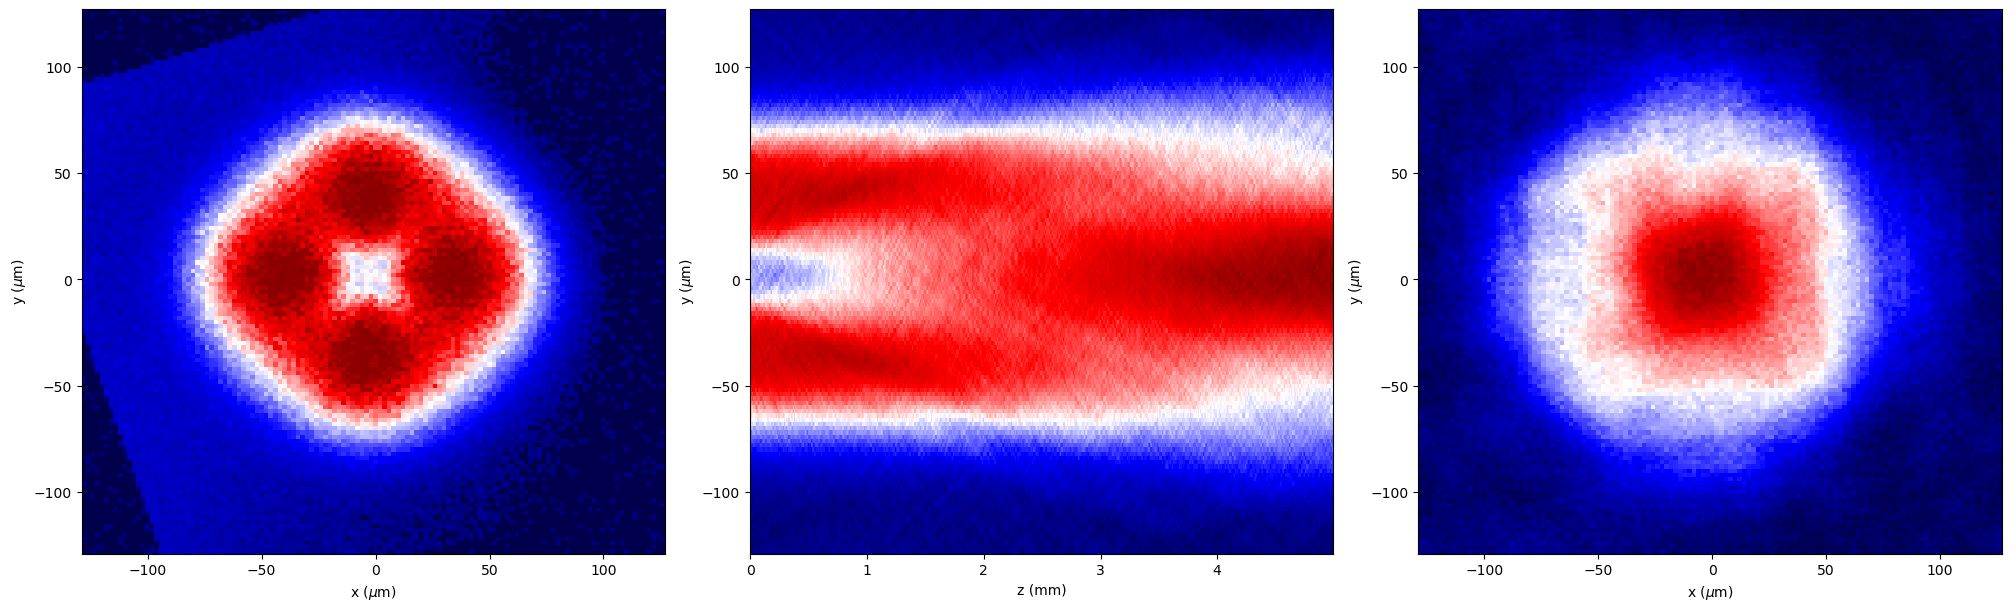

In [8]:
images_input = torch.flip(images_E[0], [0])
field = propagation_along_z(images_input, wl, N_pixels, DISCRETIZATION_STEP, z_step, number_of_z_steps)

plt.rcParams["figure.figsize"] = (20, 6)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, constrained_layout=True)
cmap = 'seismic'

# input
XY_field_in = np.abs(field[0].data.numpy())
ax1.pcolormesh(mesh*10**6, mesh*10**6, XY_field_in, cmap=cmap)
ax1.set_xlabel('x ($\mu$m)')
ax1.set_ylabel('y ($\mu$m)')

# yz cross-section
YZ_field = torch.abs(field[:, :, N_pixels//2])
ax2.pcolormesh(z*10**3, mesh*10**6, YZ_field.T, cmap=cmap)
ax2.set_xlabel('z (mm)')
ax2.set_ylabel('y ($\mu$m)')

# output
XY_field_out = torch.abs(field[-1]).T
ax3.pcolormesh(mesh*10**6, mesh*10**6, XY_field_out.T, cmap=cmap)
ax3.set_xlabel('x ($\mu$m)')
ax3.set_ylabel('y ($\mu$m)')

plt.show()

In [9]:
class Lens_Layer(torch.nn.Module):
    # 模型初始化（构造实例），默认实参波长为830e-9，网格总数50，网格大小20e-6，z方向传播0.002。
    def __init__(self, f = 5e-3, wl = 830e-9, N_pixels = 128, pixel_size = 2e-6, distance = torch.tensor([0.005])):
        super(Lens_Layer, self).__init__() # 初始化父类
        # 网格大小
        coord_limit = (N_pixels//2)*pixel_size # 建立xy坐标系
        # 拉网格
        mesh = np.arange(-coord_limit, coord_limit, pixel_size)
        x, y = np.meshgrid(mesh, mesh)
        self.phase_lens = torch.tensor(np.exp(-1j*np.pi/(wl*f) * (x**2 + y**2))).to(device)
        
        # 以1/d为单位频率，得到一系列频率分量[0, 1, 2, ···, N_pixels/2-1,-N_pixels/2, ···, -1]/(N_pixels*d)。
        fx = np.fft.fftshift(np.fft.fftfreq(N_pixels, d = pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(N_pixels, d = pixel_size))
        fxx, fyy = np.meshgrid(fx, fy) # 拉网格，每个网格坐标点为空间频率各分量。

        argument = (2 * np.pi)**2 * ((1. / wl) ** 2 - fxx ** 2 - fyy ** 2)

        # 计算传播场或倏逝场的模式kz，传播场kz为实数，倏逝场kz为复数
        tmp = np.sqrt(np.abs(argument))
        self.distance = distance.to(device)
        self.kz = torch.tensor(np.where(argument >= 0, tmp, 1j*tmp)).to(device)

    def forward(self, E):
        # 定义单个衍射层内的前向传播
        fft_c = torch.fft.fft2(E) # 对电场E进行二维傅里叶变换
        c = torch.fft.fftshift(fft_c).to(device) # 将零频移至张量中心
        phase = torch.exp(1j * self.kz * self.distance).to(device)
        angular_spectrum = torch.fft.ifft2(torch.fft.ifftshift(c * phase)) # 卷积后逆变换得到响应的角谱
        return angular_spectrum*self.phase_lens

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\601910562.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('x ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\601910562.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('y ($\mu$m)')


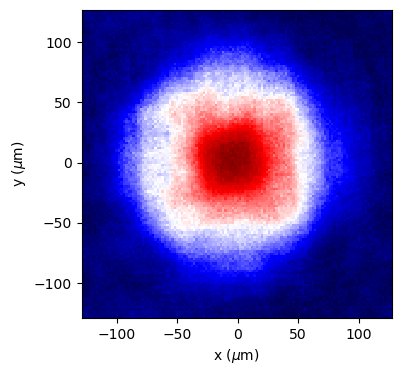

In [10]:
# 不看中间的光束传输过程，可以根据角谱直接计算出z位置的光场分布，结果与考虑传输过程相同
images_input = torch.flip(images_E[0], [0])
field_test = Lens_Layer(distance=torch.tensor(5e-3))(images_input)

# output
plt.rcParams["figure.figsize"] = (4, 4)
fig, ax = plt.subplots(1)
XY_field_out = torch.abs(field_test).T.cpu().numpy()
ax.pcolormesh(mesh*10**6, mesh*10**6, XY_field_out.T, cmap=cmap)
ax.set_xlabel('x ($\mu$m)')
ax.set_ylabel('y ($\mu$m)')

plt.show()

In [11]:
# 在傅里叶平面上设置一个正方形光阑，光阑矩阵
square_aper = torch.zeros((N_pixels,N_pixels), dtype = torch.double)
L_side = int(N_pixels*1) # 1：全透，1/2中央二分之一区域透光
x1 = int((N_pixels-L_side)/2)
x2 = int((N_pixels+L_side)/2)
square_aper[x1:x2, x1:x2] = 1 # 设置探测器区域

f = 5e-3
field_lens1 = field[-1]*np.exp(-1j*np.pi/(wl*f) * (x**2 + y**2))
field_out_lens1_F1 = propagation_along_z(field_lens1, wl, N_pixels, DISCRETIZATION_STEP, z_step, number_of_z_steps)
field_out_lens1_F1[-1] = field_out_lens1_F1[-1] * square_aper
field_out_lens1_F2 = propagation_along_z(field_out_lens1_F1[-1], wl, N_pixels, DISCRETIZATION_STEP, z_step, number_of_z_steps)
field_lens2 = field_out_lens1_F2[-1]*np.exp(-1j*np.pi/(wl*f) * (x**2 + y**2))
field_out_lens2 = propagation_along_z(field_lens2, wl, N_pixels, DISCRETIZATION_STEP, z_step, number_of_z_steps)

YZ_field_lens1_F1 = torch.abs(field_out_lens1_F1[:, N_pixels//2])
YZ_field_lens1_F2 = torch.abs(field_out_lens1_F2[:, N_pixels//2])
YZ_field_lens2 = torch.abs(field_out_lens2[:, N_pixels//2])
YZ_field_total = torch.cat((YZ_field, YZ_field_lens1_F1, YZ_field_lens1_F2, YZ_field_lens2), dim = 0)
z_total = np.arange(0, 4*number_of_z_steps)*z_step # z坐标

C:\Users\zc\AppData\Local\Temp\ipykernel_10536\3885851688.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  field_lens1 = field[-1]*np.exp(-1j*np.pi/(wl*f) * (x**2 + y**2))
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\3885851688.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  field_lens2 = field_out_lens1_F2[-1]*np.exp(-1j*np.pi/(wl*f) * (x**2 + y**2))


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\1766724965.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('y ($\mu$m)')


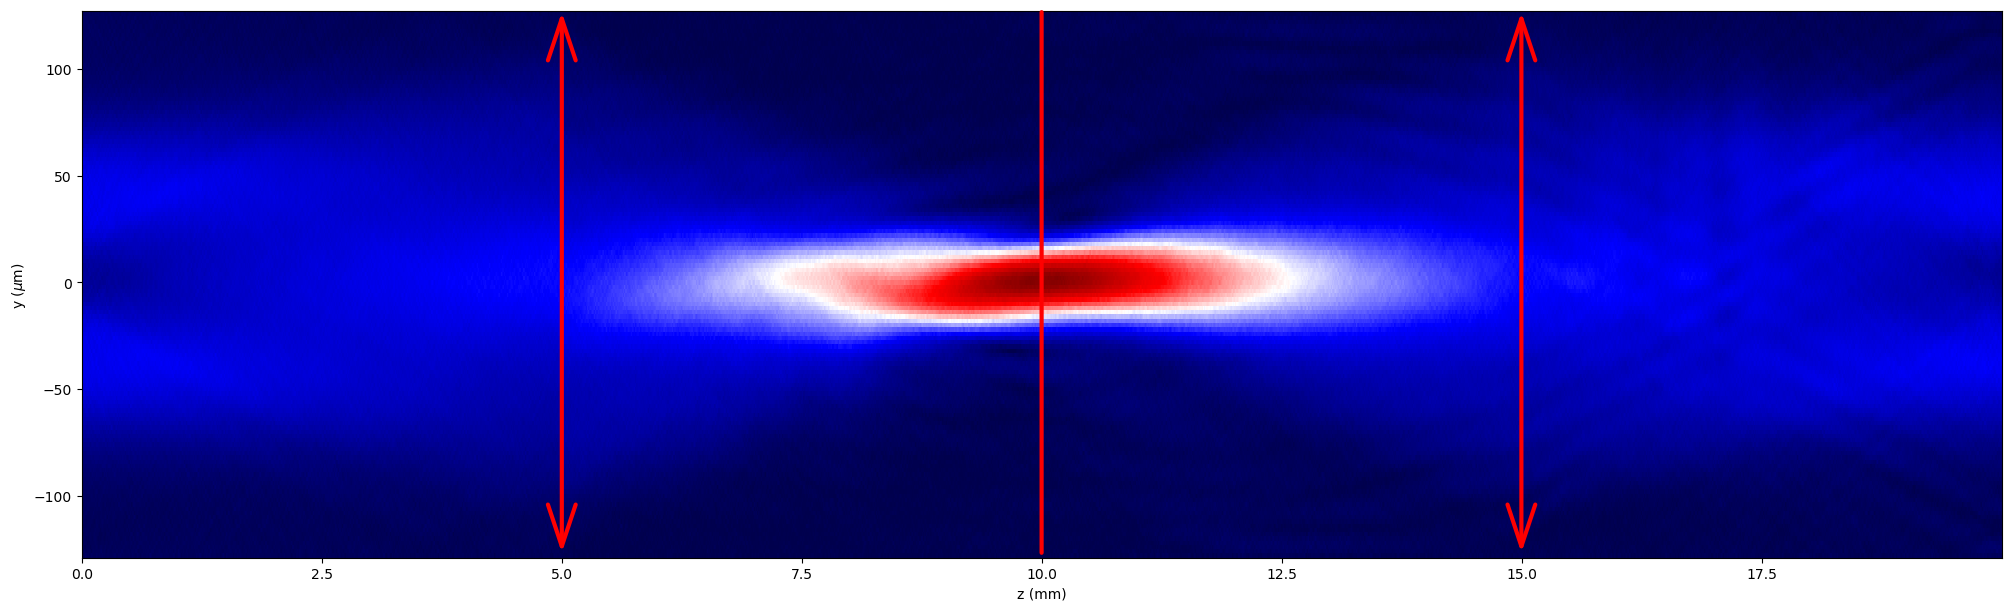

In [12]:
plt.rcParams["figure.figsize"] = (20, 6)
# yx cross-section
fig, ax = plt.subplots(1, constrained_layout=True)
ax.pcolormesh(z_total*10**3, mesh*10**6, YZ_field_total.T, cmap = 'seismic')
ax.set_xlabel('z (mm)')
ax.set_ylabel('y ($\mu$m)')

plt.annotate('', xy=(max(z_total*10**3)/4, -coord_limit*10**6), xytext=(max(z_total*10**3)/4, coord_limit*10**6), 
             arrowprops=dict(arrowstyle='<->, head_length=3, head_width=1', lw=3, color='red'))

plt.annotate('', xy=(max(z_total*10**3)/2, -coord_limit*10**6), xytext=(max(z_total*10**3)/2, coord_limit*10**6), 
             arrowprops=dict(arrowstyle='-', lw=3, color='red'))

plt.annotate('', xy=(max(z_total*10**3)*3/4, -coord_limit*10**6), xytext=(max(z_total*10**3)*3/4, coord_limit*10**6), 
             arrowprops=dict(arrowstyle='<->, head_length=3, head_width=1', lw=3, color='red'))

plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\699772109.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('x ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\699772109.py:7: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('y ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\699772109.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('x ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\699772109.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('y ($\mu$m)')


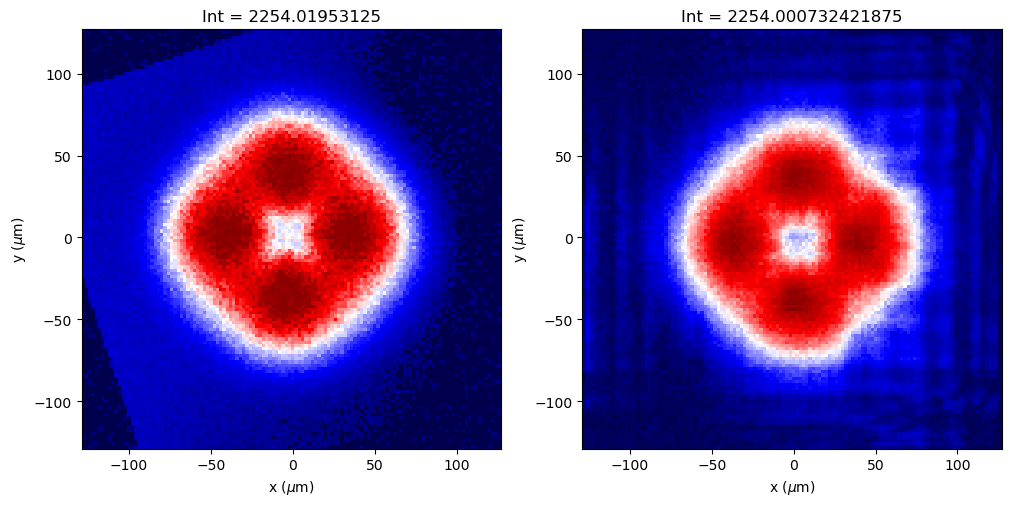

In [13]:
plt.rcParams["figure.figsize"] = (10, 10)
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True)
# input
XY_field_in = np.abs(field[0].data.numpy())
ax1.pcolormesh(mesh*10**6, mesh*10**6, XY_field_in, cmap=cmap)
ax1.set_xlabel('x ($\mu$m)')
ax1.set_ylabel('y ($\mu$m)')
ax1.set_aspect('equal')
ax1.set_title('Int = {}'.format(torch.pow(abs(torch.tensor(XY_field_in)), 2).sum()))

# output
XY_field_out_lens2 = torch.abs(field_out_lens2[-1]).T
ax2.pcolormesh(mesh*10**6, mesh*10**6, XY_field_out_lens2.T, cmap=cmap)
ax2.set_xlabel('x ($\mu$m)')
ax2.set_ylabel('y ($\mu$m)')
ax2.set_aspect('equal')
ax2.set_title('Int = {}'.format(torch.pow(abs(XY_field_out_lens2), 2).sum()))

plt.axis('square')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\1659026710.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('x ($\mu$m)')
C:\Users\zc\AppData\Local\Temp\ipykernel_10536\1659026710.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('y ($\mu$m)')


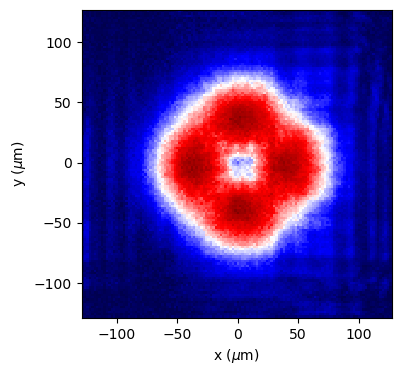

In [14]:
# 在傅里叶平面上设置一个正方形光阑，光阑矩阵
square_aper = torch.zeros((N_pixels,N_pixels), dtype = torch.double)
L_side = int(N_pixels*1) # 1：全透，1/2中央二分之一区域透光
x1 = int((N_pixels-L_side)/2)
x2 = int((N_pixels+L_side)/2)
square_aper[x1:x2, x1:x2] = 1 # 设置探测器区域

# 不看中间的光束传输过程，可以根据角谱直接计算出z位置的光场分布，结果与考虑传输过程相同
images_input = torch.flip(images_E[0], [0])
field_test1 = Lens_Layer(distance=torch.tensor(5e-3))(images_input) # 物面到第一个lens
field_test2 = Diffractive_Layer(distance=torch.tensor(5e-3))(field_test1) # 第一个lens到傅里叶平面
field_test3 = field_test2 * square_aper.to(device) # 经过傅里叶平面的光阑
field_test4 = Lens_Layer(distance=torch.tensor(5e-3))(field_test3) # 傅里叶平面到第二个lens
field_test5 = Propagation_Layer(distance=torch.tensor(5e-3))(field_test4) # 第二个lens到像面

# output
plt.rcParams["figure.figsize"] = (4, 4)
fig, ax = plt.subplots(1)
XY_field_out = torch.abs(field_test5).T.cpu().numpy()
ax.pcolormesh(mesh*10**6, mesh*10**6, XY_field_out.T, cmap=cmap)
ax.set_xlabel('x ($\mu$m)')
ax.set_ylabel('y ($\mu$m)')

plt.show()

### ***Detectors Layer***

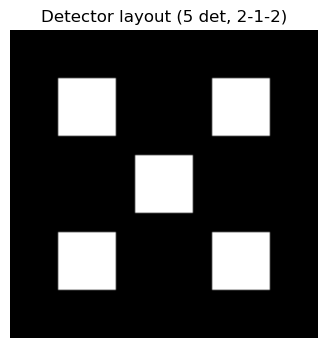

Detector positions (up, down, left, right):
  det[0] = (20, 44, 20, 44)
  det[1] = (20, 44, 84, 108)
  det[2] = (52, 76, 52, 76)
  det[3] = (84, 108, 20, 44)
  det[4] = (84, 108, 84, 108)


In [15]:
# 生成一行探测器。指定探测器个数N_det，在x方向上生成齐高等间距det_step的一组探测器
# left，right，up和down分别是该行矩形探测器的四个顶点坐标。
def generate_det_row(det_size, start_pos_x, start_pos_y, det_step, N_det):
    p = []
    for i in range(N_det):
        left = start_pos_x + i * (int(det_step) + det_size)
        right = left + det_size
        up = start_pos_y
        down = start_pos_y + det_size
        p.append((up, down, left, right))
    return p

# 获取最终衍射光强在各个探测器上的分布情况
def detector_region_logits(Int):
    """
    Int: [B, H, W] intensity (float)
    返回: logits [B, C] = 每个探测器区域的总强度（未归一化）
    """
    region_scores = []
    # detector_pos 中保存 (up, down, left, right)
    for up, down, left, right in detector_pos:
        region_sum = Int[:, up:down, left:right].sum(dim=(1, 2))  # [B]
        region_scores.append(region_sum)
    logits = torch.stack(region_scores, dim=1)  # [B, C]
    return logits
# 你训练集类别数
num_classes = len(train_dataset.classes)


# 5 个 detector，3x3 网格，2-1-2 分布
# 设计参数（可调）
det_size = 24
gap = 8

# 以 3x3 为参考网格，整体居中
grid_n = 3
total_width = grid_n * det_size + (grid_n - 1) * gap
start_pos_x = (N_pixels - total_width) // 2
start_pos_y = (N_pixels - total_width) // 2

# 2-1-2 布局（坐标为网格列索引）
layout = [
    (0, [0, 2]),   # 第 1 行：2 个（左、中右）
    (1, [1]),      # 第 2 行：1 个（正中）
    (2, [0, 2])    # 第 3 行：2 个（左、右）
]

detector_pos = []
for row, cols in layout:
    for col in cols:
        left = start_pos_x + col * (det_size + gap)
        right = left + det_size
        up = start_pos_y + row * (det_size + gap)
        down = up + det_size
        detector_pos.append((up, down, left, right))

# 生成 labels_image_tensors
num_classes = 5
labels_image_tensors = torch.zeros((num_classes, N_pixels, N_pixels), device=device, dtype=torch.float32)
for ind, pos in enumerate(detector_pos):
    up, down, left, right = pos
    labels_image_tensors[ind, up:down, left:right] = 1.0
    labels_image_tensors[ind] = labels_image_tensors[ind] / labels_image_tensors[ind].sum()

# 可视化 layout
det_ideal = labels_image_tensors.cpu().numpy().sum(axis=0)
plt.figure(figsize=(4,4))
plt.imshow(det_ideal, cmap="gray", origin="upper")
plt.title("Detector layout (5 det, 2-1-2)")
plt.axis('off')
plt.show()

# 打印位置
print("Detector positions (up, down, left, right):")
for i, p in enumerate(detector_pos):
    print(f"  det[{i}] = {p}")

### ***D2NN***

In [16]:
# ===== 新增: 相位映射与STE量化 =====
def param_to_phase(param, phi_max=np.pi, mapping='sigmoid'):
    if mapping == 'sigmoid':
        return phi_max * torch.sigmoid(param)
    elif mapping == 'linear':
        return phi_max * torch.clamp(param, 0.0, 1.0)
    else:
        raise ValueError(f"Unknown mapping: {mapping}")

def ste_quantize_phase_from_param(param, phi_max=np.pi, n_levels=4, mapping='sigmoid'):
    phi_cont = param_to_phase(param, phi_max=phi_max, mapping=mapping)
    levels = torch.linspace(
        0.0, phi_max * (n_levels - 1) / n_levels, steps=n_levels,
        device=phi_cont.device, dtype=phi_cont.dtype
    )
    idx = torch.argmin(torch.abs(phi_cont.unsqueeze(-1) - levels), dim=-1)
    phi_q = levels[idx]
    # STE
    phi_q_ste = phi_cont + (phi_q - phi_cont).detach()
    return phi_q_ste

In [17]:
# 先做一个模型初始化，将生成的初始随机相位参数与模型分离，以便于后面对其他参数分别训练。
# 初始化每层相位板的相位参数（0到1区间均匀分布）,并将其注册为可学习的Parameter。
num_layers = 3
distance_between_layers = 0.004, 0.004, 0.004, 0.005
phase = [
    torch.nn.Parameter(torch.zeros((N_pixels, N_pixels), dtype=torch.float32))
    for _ in range(num_layers)
]

distance_between_layers = [0.004, 0.004,0.004, 0.004, 0.005]  # 长度必须= num_layers+2 = 5
distance = [
    torch.nn.Parameter(torch.tensor([distance_between_layers[i]], dtype=torch.float32))
    for i in range(num_layers + 2)
]

print("len(phase) =", len(phase))       # 应该是 2
print("len(distance) =", len(distance)) # 应该是 4

len(phase) = 3
len(distance) = 5


In [18]:
distance[1]

Parameter containing:
tensor([0.0040], requires_grad=True)

In [19]:
class DNN(torch.nn.Module):
    """""""""""""""""""""
    phase & amplitude modulation
    """""""""""""""""""""
    def __init__(self, phase = [], num_layers = 3, wl = 830e-9, N_pixels = 128, pixel_size = 20e-6,
             distance = [], detector_pos=None, phase_mapping='sigmoid',
             quantize_during_train=False, quant_levels=4):

        super(DNN, self).__init__()
        
        # 初始化每层相位板的相位参数（0到1区间均匀分布）,并将其注册为可学习的Parameter。
#         self.phase = [torch.nn.Parameter(torch.from_numpy(np.random.random(size=(N_pixels, N_pixels)).
#                                                           astype('float32')-0.5)) for _ in range(num_layers)]
        # 向网络中添加每层相位板的参数
        for i in range(num_layers):
            self.register_parameter("phase" + "_" + str(i), phase[i])
        # 向网络中添加每层相位板的衰减参数
#         for i in range(num_layers):
#             self.register_parameter("Amp" + "_" + str(i), Amp[i])
        # 向网络中添加层间距的参数
        for i in range(num_layers+2):
            self.register_parameter("distance" + "_" + str(i), distance[i])
        # 定义最大相位
        self.phi_max = np.pi
        self.detector_pos = detector_pos
        self.phase_mapping = phase_mapping
        self.quantize_during_train = quantize_during_train
        self.quant_levels = quant_levels

        # 定义透镜面
        self.lens_layer1 = Lens_Layer()
        
        # 定义中间的衍射层
        self.diffractive_layers = torch.nn.ModuleList([Diffractive_Layer(wl, N_pixels, pixel_size, distance[i])
                                                       for i in range(num_layers)])
        
        # 在相位板后加一层饱和吸收体，用ReLU模拟非线性
#         self.relu = torch.nn.ReLU()
        
        # 定义透镜面
        self.lens_layer2 = Lens_Layer(distance=distance[-2])
        
        # 定义最后的探测层
        self.last_diffractive_layer = Propagation_Layer(wl, N_pixels, pixel_size, distance[-1])
        self.sofmax = torch.nn.Softmax(dim=-1)
    
    # 计算多层衍射前向传播
    def forward(self, E):
        E = self.lens_layer1(E)
        for index, layer in enumerate(self.diffractive_layers):
            temp = layer(E)
            registered_phase = getattr(self, f"phase_{index}")
            if self.quantize_during_train:
                constr_phase = ste_quantize_phase_from_param(
                    registered_phase,
                    phi_max=self.phi_max,
                    n_levels=self.quant_levels,
                    mapping=self.phase_mapping
                )
            else:
                constr_phase = param_to_phase(
                    registered_phase,
                    phi_max=self.phi_max,
                    mapping=self.phase_mapping
                 )
            exp_j_phase = torch.exp(1j * constr_phase)
            E = temp * exp_j_phase
            # 【小修改】添加 eps 防止 |E|≈0 时除零产生 NaN
            E_phase = E / (torch.abs(E) + 1e-12)
            I = torch.abs(E) ** 2  # real float32
            E = torch.sqrt(I_out + 1e-12) * E_phase
        E = self.lens_layer2(E)
        E = self.last_diffractive_layer(E)
        Int = torch.abs(E)**2
#         output = self.sofmax(detector_region(Int))
        output = detector_region_logits(Int) if self.detector_pos is None else detector_region_logits(Int)
        return output, Int

In [20]:
a = torch.tensor([[[-1, 1, 1], [4, -4, 4]], [[2, 2, -2], [5, -5, 5]]]).to(dtype=torch.float64)
print(a.size())
print(a)
b = torch.mean(torch.abs(a), dim=(-2, -1), keepdim=True)
print(b.size())
c = torch.ones_like(a)*b
c.size()
print(c)

a-c

torch.Size([2, 2, 3])
tensor([[[-1.,  1.,  1.],
         [ 4., -4.,  4.]],

        [[ 2.,  2., -2.],
         [ 5., -5.,  5.]]], dtype=torch.float64)
torch.Size([2, 1, 1])
tensor([[[2.5000, 2.5000, 2.5000],
         [2.5000, 2.5000, 2.5000]],

        [[3.5000, 3.5000, 3.5000],
         [3.5000, 3.5000, 3.5000]]], dtype=torch.float64)


tensor([[[-3.5000, -1.5000, -1.5000],
         [ 1.5000, -6.5000,  1.5000]],

        [[-1.5000, -1.5000, -5.5000],
         [ 1.5000, -8.5000,  1.5000]]], dtype=torch.float64)

In [21]:
I = torch.abs(images_E)**2
I_th = torch.mean(I, dim=(-2, -1), keepdim=True)
I_th = I_th * torch.ones_like(images_E)
I_th.shape
I_out = torch.nn.ReLU()(I-I_th)
I_out.shape

torch.Size([200, 128, 128])

In [22]:
model = DNN(phase = phase, distance = distance).to(device)
print(model)

DNN(
  (lens_layer1): Lens_Layer()
  (diffractive_layers): ModuleList(
    (0-2): 3 x Diffractive_Layer()
  )
  (lens_layer2): Lens_Layer()
  (last_diffractive_layer): Propagation_Layer()
  (sofmax): Softmax(dim=-1)
)


In [23]:
# 展示可供训练的参数（因为）
for index, item in model.named_parameters():
    print(index)

phase_0
phase_1
phase_2
distance_0
distance_1
distance_2
distance_3
distance_4


In [24]:
# 先只训练相位，层间距先设定0.005。之后再在0.005这个基础上微调训练层间距。
for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if name.find('phase') != -1:
        exec('model.' + name + '.requires_grad_(True)')
# for name, param in model.named_parameters():
#     if name.find('Amp') != -1:
#         exec('model.' + name + '.requires_grad_(True)')
    
print("Params to learn:")
params_to_update = []
for name, param in model.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 phase_0
	 phase_1
	 phase_2


### ***Training***

In [25]:
def train(model, loss_function, optimizer, trainloader, testloader, epochs=10, device='cpu', filename='best.pt'):
    """
    训练函数（含诊断）
    - 修复输入维度：squeeze(1)
    - 诊断参数是否更新：phase_0 mean |delta|
    - 诊断预测是否塌缩：val pred hist
    """
    import copy
    import torch
    from tqdm import tqdm

    train_loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    # 设备一致性检查（防止 optimizer 混用 cpu/cuda）
    opt_devices = {str(p.device) for g in optimizer.param_groups for p in g["params"]}
    if len(opt_devices) != 1:
        raise RuntimeError(f"Optimizer 参数存在多设备混用: {opt_devices}")

    # 自动推断类别数（用于pred直方图）
    try:
        num_classes_local = len(trainloader.dataset.classes)
    except Exception:
        num_classes_local = None

    for epoch in range(epochs):
        # ========== Training ==========
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for i, (images, labels) in enumerate(tqdm(trainloader, desc=f"Train {epoch+1}/{epochs}")):
            images = torch.sqrt(images.to(device).squeeze(1))   # 关键：不能用 squeeze()
            labels = labels.to(device).long()

            optimizer.zero_grad()

            # 记录 step 前参数（用于检查是否真的更新）
            with torch.no_grad():
                p0_before = None
                if hasattr(model, "phase_0"):
                    p0_before = model.phase_0.detach().clone()

            # Forward
            out_label, out_img = model(images)
            out_label = out_label.to(dtype=torch.float32)

            # Loss
            loss = loss_function(out_label, labels)
            loss.backward()

            # （可选）梯度裁剪，提升稳定性
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # # step后参数变化诊断（只打印前3个batch，避免刷屏）
            # if i < 3 and p0_before is not None:
            #     with torch.no_grad():
            #         delta = (model.phase_0 - p0_before).abs().mean().item()
            #     print("phase_0 mean |delta| =", delta)

            # Stats
            running_loss += loss.item()
            _, predicted = torch.max(out_label, 1)
            running_correct += (predicted == labels).sum().item()
            running_total += labels.size(0)

        epoch_train_loss = running_loss / max(1, len(trainloader))
        epoch_train_acc = running_correct / max(1, running_total)
        train_loss_hist.append(epoch_train_loss)
        train_acc_hist.append(epoch_train_acc)

        # ========== Validation ==========
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        # 预测分布统计（判断是否塌缩）
        pred_hist = None
        if num_classes_local is not None:
            pred_hist = torch.zeros(num_classes_local, dtype=torch.int64)

        with torch.no_grad():
            for images, labels in tqdm(testloader, desc=f"Val   {epoch+1}/{epochs}"):
                images = torch.sqrt(images.to(device).squeeze(1))  # 关键：不能用 squeeze()
                labels = labels.to(device).long()

                out_label, out_img = model(images)
                out_label = out_label.to(dtype=torch.float32)

                loss = loss_function(out_label, labels)
                val_loss += loss.item()

                _, predicted = torch.max(out_label, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                if pred_hist is not None:
                    pred_cpu = predicted.detach().cpu()
                    for c in range(num_classes_local):
                        pred_hist[c] += (pred_cpu == c).sum()

        epoch_val_loss = val_loss / max(1, len(testloader))
        epoch_val_acc = val_correct / max(1, val_total)
        test_loss_hist.append(epoch_val_loss)
        test_acc_hist.append(epoch_val_acc)

        # Save best
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            state = {
                'state_dict': model.state_dict(),
                'best_acc': best_acc,
                'optimizer': optimizer.state_dict(),
            }
            torch.save(state, filename)

        # Epoch log
        print(f"Epoch={epoch+1}/{epochs} train_loss={epoch_train_loss:.4f}, val_loss={epoch_val_loss:.4f}")
        print(f"train_acc={epoch_train_acc:.4f}, val_acc={epoch_val_acc:.4f}")
        if pred_hist is not None:
            print("val pred hist:", pred_hist.tolist())
        print("-----------------------")

    model.load_state_dict(best_model_wts)
    return train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist, model

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_training_curves_return_fig(train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, title_prefix=""):
    epochs = range(1, len(train_loss_hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, train_loss_hist, marker='o', label='Train Loss')
    axes[0].plot(epochs, val_loss_hist, marker='s', label='Val Loss')
    axes[0].set_title(f'{title_prefix} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, train_acc_hist, marker='o', label='Train Acc')
    axes[1].plot(epochs, val_acc_hist, marker='s', label='Val Acc')
    axes[1].set_title(f'{title_prefix} Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.0)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    return fig

def fig_to_rgb_array(fig):
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    return buf.reshape(h, w, 3)

In [27]:
def custom_loss(imgs, det_labels):
    full_int = imgs.sum(dim=(1,2))
    loss = 1 - (imgs*det_labels).sum(dim=(1,2))/full_int
    return loss.mean()

In [28]:
# 定义衍射模型基本参数
wl = 830e-9
pixel_size = 2e-6

# ========= 1) 构建模型 =========
model = DNN(
    phase=phase, num_layers=3, wl=wl, pixel_size=pixel_size, distance=distance,
    detector_pos=detector_pos,
    phase_mapping='sigmoid',          # 统一口径
    quantize_during_train=False,      # 先连续 warmup
    quant_levels=4
).to(device)

# ========= 2) 损失函数 =========
criterion = torch.nn.CrossEntropyLoss().to(device)

# ========= 3) 训练参数开关（第一阶段：只训 phase） =========
for p in model.parameters():
    p.requires_grad = False

for name, p in model.named_parameters():
    if name.startswith("phase_"):
        p.requires_grad_(True)

# 重新收集可训练参数（不要复用旧的 params_to_update）
params_to_update = [p for p in model.parameters() if p.requires_grad]

print("Params to learn:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print("  ", name)

print("num trainable params =", len(params_to_update))
print("trainable devices =", {str(p.device) for p in params_to_update})

# 防呆：确保优化器里只有单一设备参数
assert len(params_to_update) > 0, "没有可训练参数，请检查 requires_grad 设置。"
assert len({str(p.device) for p in params_to_update}) == 1, "可训练参数跨设备(CPU/GPU)混用。"

# ========= 4) 优化器 =========
optimizer = torch.optim.Adam(params_to_update, lr=0.002)

# （可选）训练前做一步设备检查
opt_devices = {str(p.device) for g in optimizer.param_groups for p in g["params"]}
print("optimizer param devices =", opt_devices)
assert len(opt_devices) == 1, f"Optimizer 参数存在多设备混用: {opt_devices}"

Params to learn:
   phase_0
   phase_1
   phase_2
num trainable params = 3
trainable devices = {'cuda:0'}
optimizer param devices = {'cuda:0'}


In [29]:
# 正式开启训练
train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist, best_model = train(model, 
                          criterion,optimizer, train_dataloader, val_dataloader, epochs = 30,  device = device)

Val   1/30: 100%|██████████| 30/30 [00:05<00:00,  5.94it/s]


Epoch=1/30 train_loss=233.4746, val_loss=202.7094
train_acc=0.2010, val_acc=0.2018
val pred hist: [6, 10, 5927, 13, 44]
-----------------------


Val   2/30: 100%|██████████| 30/30 [00:05<00:00,  5.74it/s]


Epoch=2/30 train_loss=168.8523, val_loss=131.8404
train_acc=0.2097, val_acc=0.2162
val pred hist: [140, 32, 5354, 168, 306]
-----------------------


Val   3/30: 100%|██████████| 30/30 [00:08<00:00,  3.55it/s]


...

Epoch=28/30 train_loss=0.4920, val_loss=0.4851
train_acc=0.8407, val_acc=0.8398
val pred hist: [1178, 1185, 1251, 1156, 1230]
-----------------------


Val   29/30: 100%|██████████| 30/30 [00:04<00:00,  6.05it/s]


Epoch=29/30 train_loss=0.4698, val_loss=0.4641
train_acc=0.8450, val_acc=0.8465
val pred hist: [1180, 1171, 1218, 1234, 1197]
-----------------------


Val   30/30: 100%|██████████| 30/30 [00:05<00:00,  5.86it/s]


Epoch=30/30 train_loss=0.4530, val_loss=0.4515
train_acc=0.8460, val_acc=0.8487
val pred hist: [1177, 1187, 1234, 1179, 1223]
-----------------------


In [31]:
print([k for k in globals().keys() if ('loss' in k or 'acc' in k) and ('hist' in k)])

['train_loss_hist', 'train_acc_hist', 'test_loss_hist', 'test_acc_hist']


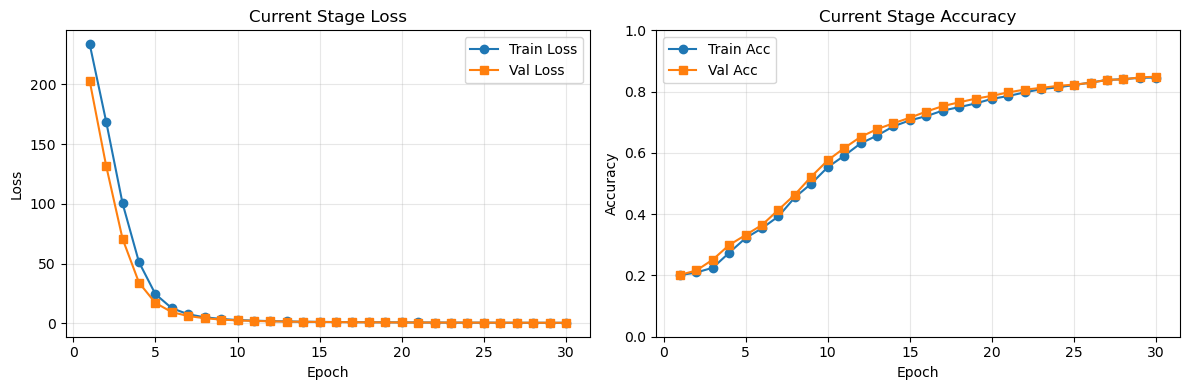

In [32]:
# 先把当前曲线图保存
fig_cur = plot_training_curves_return_fig(
    train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist,
    title_prefix="Current Stage"
)
fig_cur.savefig("current_stage.png", dpi=200, bbox_inches='tight')
plt.show()

In [33]:
# 查看训练的各个参数，确保这一次只有相位被训练了（requires_grad=True）
for param in model.named_parameters():
    print(param)

('phase_0', Parameter containing:
tensor([[ 0.0311, -0.1757, -0.2076,  ...,  0.0156, -0.0232, -0.0900],
        [-0.1473, -0.1519,  0.1403,  ..., -0.0779, -0.0781, -0.0105],
        [-0.0372,  0.0486,  0.0967,  ..., -0.0403,  0.0158, -0.2008],
        ...,
        [ 0.0116, -0.1561,  0.1654,  ...,  0.0233, -0.1700, -0.0357],
        [ 0.0180, -0.1190,  0.0657,  ..., -0.0297,  0.1046, -0.0344],
        [-0.1080,  0.0352, -0.1011,  ...,  0.0206,  0.0640, -0.0034]],
       device='cuda:0', requires_grad=True))
('phase_1', Parameter containing:
tensor([[-0.2685,  0.0969, -0.0608,  ..., -0.0077,  0.4002, -0.0109],
        [ 0.3404, -0.0387, -0.2188,  ..., -0.1308, -0.1308, -0.1381],
        [-0.0749, -0.0635,  0.1165,  ..., -0.2509, -0.1666, -0.0711],
        ...,
        [-0.0805, -0.0386,  0.0098,  ...,  0.0474,  0.0245, -0.1451],
        [ 0.1723, -0.0463, -0.3996,  ...,  0.0968,  0.0204,  0.0544],
        [-0.2476, -0.1399,  0.3772,  ...,  0.1997,  0.1044, -0.3439]],
       device='cuda

In [34]:
# 全部解禁，相位和层间距都拿来训练
for param in model.parameters():
    param.requires_grad = True

# for name, param in model.named_parameters():
#     if name.find('distance') != -1:
#         exec('model.' + name + '.requires_grad_(True)')

print("Params to learn:")
params_to_update = []
for name, param in model.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 phase_0
	 phase_1
	 phase_2
	 distance_0
	 distance_1
	 distance_2
	 distance_3
	 distance_4


In [35]:
# 加载之前训练好的参数
checkpoint = torch.load('best.pt')
best_acc = checkpoint['best_acc']
model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [36]:
# 加载损失函数和优化器
# criterion = torch.nn.MSELoss(reduction='sum').to(device)
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params_to_update, lr=1e-7)

In [37]:
# 重新开启训练
train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist, best_model = train(model, 
                          criterion,optimizer, train_dataloader, val_dataloader, epochs = 10,  device = device)

Val   1/10: 100%|██████████| 30/30 [00:05<00:00,  5.95it/s]


Epoch=1/10 train_loss=0.4584, val_loss=0.4503
train_acc=0.8492, val_acc=0.8510
val pred hist: [1173, 1189, 1272, 1172, 1194]
-----------------------


Val   2/10: 100%|██████████| 30/30 [00:09<00:00,  3.11it/s]


Epoch=2/10 train_loss=0.4449, val_loss=0.4516
train_acc=0.8515, val_acc=0.8500
val pred hist: [1172, 1211, 1207, 1169, 1241]
-----------------------


Val   3/10: 100%|██████████| 30/30 [00:05<00:00,  5.99it/s]


...

Epoch=8/10 train_loss=0.4477, val_loss=0.4494
train_acc=0.8496, val_acc=0.8513
val pred hist: [1166, 1205, 1229, 1163, 1237]
-----------------------


Val   9/10: 100%|██████████| 30/30 [00:05<00:00,  5.02it/s]


Epoch=9/10 train_loss=0.4466, val_loss=0.4476
train_acc=0.8519, val_acc=0.8537
val pred hist: [1173, 1197, 1236, 1179, 1215]
-----------------------


Val   10/10: 100%|██████████| 30/30 [00:05<00:00,  5.98it/s]

Epoch=10/10 train_loss=0.4471, val_loss=0.4506
train_acc=0.8514, val_acc=0.8527
val pred hist: [1167, 1208, 1230, 1156, 1239]
-----------------------


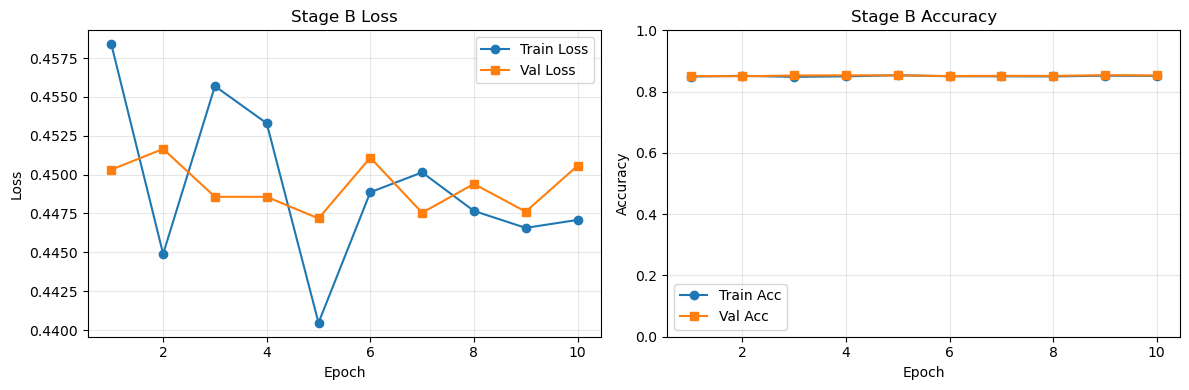

In [38]:
# 第二阶段训练后，先保存第二阶段曲线图
fig_stageB = plot_training_curves_return_fig(
    train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist,
    title_prefix="Stage B"
)
fig_stageB.savefig("stageB.png", dpi=200, bbox_inches='tight')
plt.show()

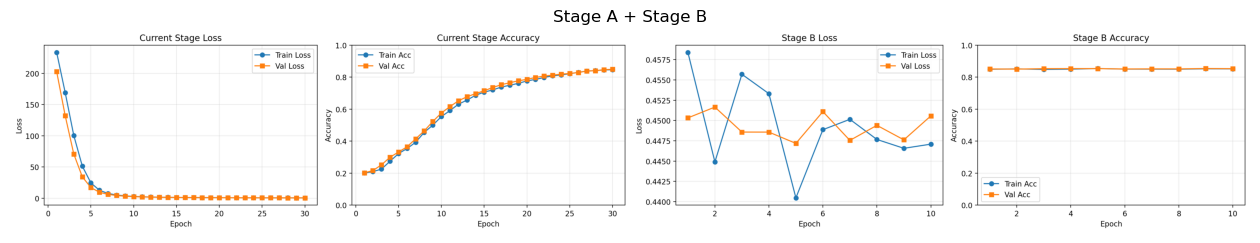

In [39]:
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt

imgA = mpimg.imread('current_stage.png')   # 第一阶段
imgB = mpimg.imread('stageB.png')   # 第二阶段

h = min(imgA.shape[0], imgB.shape[0])
merged = np.concatenate([imgA[:h, ...], imgB[:h, ...]], axis=1)

plt.figure(figsize=(16,5))
plt.imshow(merged)
plt.axis('off')
plt.title('Stage A + Stage B')
plt.show()

plt.imsave('merged_stageA_stageB.png', merged)

In [40]:
for name, param in model.named_parameters():
    print(param)

Parameter containing:
tensor([[ 0.0311, -0.1757, -0.2076,  ...,  0.0156, -0.0232, -0.0900],
        [-0.1473, -0.1519,  0.1403,  ..., -0.0779, -0.0781, -0.0105],
        [-0.0372,  0.0486,  0.0967,  ..., -0.0403,  0.0158, -0.2008],
        ...,
        [ 0.0116, -0.1561,  0.1654,  ...,  0.0233, -0.1700, -0.0357],
        [ 0.0180, -0.1190,  0.0657,  ..., -0.0297,  0.1046, -0.0344],
        [-0.1080,  0.0352, -0.1011,  ...,  0.0206,  0.0640, -0.0034]],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-0.2685,  0.0969, -0.0608,  ..., -0.0077,  0.4002, -0.0109],
        [ 0.3404, -0.0387, -0.2188,  ..., -0.1308, -0.1308, -0.1381],
        [-0.0749, -0.0635,  0.1165,  ..., -0.2509, -0.1666, -0.0711],
        ...,
        [-0.0805, -0.0386,  0.0098,  ...,  0.0474,  0.0245, -0.1451],
        [ 0.1723, -0.0463, -0.3996,  ...,  0.0968,  0.0204,  0.0544],
        [-0.2476, -0.1399,  0.3772,  ...,  0.1997,  0.1044, -0.3439]],
       device='cuda:0', requires_grad=True)


In [41]:
# === 插入点：放在训练结束后 ===
import copy
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def detect_phase_mapping(model):
    mins, maxs = [], []
    for name, p in model.named_parameters():
        if name.startswith("phase_"):
            arr = p.detach().cpu().numpy()
            mins.append(float(np.min(arr)))
            maxs.append(float(np.max(arr)))
    if not mins:
        raise RuntimeError("模型中未找到以 'phase_' 开头的参数。")
    min_all, max_all = min(mins), max(maxs)
    return 'linear' if (min_all >= -1e-6 and max_all <= 1.0 + 1e-6) else 'sigmoid'

def quantize_model_phases_consistent(model_src, L, mapping=None, eps=1e-6):
    model_q = copy.deepcopy(model_src)
    device_q = next(model_q.parameters()).device

    # 优先使用传入 mapping；否则回退到模型属性或自动检测
    if mapping is None:
        mapping = getattr(model_src, "phase_mapping", None)
    if mapping is None:
        mapping = detect_phase_mapping(model_src)

    # 训练口径优先：model.phi_max；否则默认 π
    phi_max = float(getattr(model_src, "phi_max", np.pi))
    levels = torch.linspace(0.0, phi_max * (L - 1) / L, L, dtype=torch.float32)

    src_params = dict(model_src.named_parameters())
    q_params = dict(model_q.named_parameters())

    for name, param in src_params.items():
        if not name.startswith("phase_"):
            continue

        p = param.detach().cpu().float()

        if mapping == 'sigmoid':
            phi = phi_max * torch.sigmoid(p)
            diffs = torch.abs(phi.unsqueeze(-1) - levels.unsqueeze(0))
            idx = torch.argmin(diffs, dim=-1)
            phi_q = levels[idx]
            s_q = (phi_q / phi_max).clamp(eps, 1 - eps)
            p_q = torch.log(s_q / (1 - s_q))
        elif mapping == 'linear':
            p01 = torch.clamp(p, 0.0, 1.0)
            phi = phi_max * p01
            diffs = torch.abs(phi.unsqueeze(-1) - levels.unsqueeze(0))
            idx = torch.argmin(diffs, dim=-1)
            phi_q = levels[idx]
            p_q = (phi_q / phi_max).clamp(0.0, 1.0)
        else:
            raise ValueError(f"Unknown mapping: {mapping}")

        q_params[name].data.copy_(p_q.to(device_q).to(dtype=q_params[name].dtype))

    return model_q

def evaluate_accuracy_model(model_in, dataloader, device):
    model_in.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = torch.sqrt(images.to(device).squeeze(1))  # 关键修复
            labels = labels.to(device).long()
            out = model_in(images)
            if isinstance(out, (tuple, list)):
                out = out[0]
            out = out.to(torch.float32)
            _, predicted = torch.max(out, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total if total > 0 else 0.0

# ---------- 主流程 ----------
if 'val_dataloader' not in globals():
    raise RuntimeError("val_dataloader 未在当前会话中找到。")
if 'model' not in globals():
    raise RuntimeError("model 未在当前会话中找到。")

model.to(device)
model.eval()

mapping = detect_phase_mapping(model)   # 修复：用 model，不是 model_q
print("Detected phase mapping:", mapping)

acc_orig = evaluate_accuracy_model(model, val_dataloader, device)
print(f"Original validation accuracy: {acc_orig*100:.2f}%")

quantized_states = {}
for L in (4, 8, 16):
    print(f"\nQuantizing to {L} levels...")
    model_q = quantize_model_phases_consistent(model, L, mapping=mapping)
    model_q.to(device)
    acc_q = evaluate_accuracy_model(model_q, val_dataloader, device)
    print(f"{L}-level quantized validation accuracy: {acc_q*100:.2f}%")
    print(f"Absolute drop: {(acc_orig - acc_q) * 100.0:.2f} percentage points")
    quantized_states[f"model_{L}_state_dict"] = model_q.state_dict()

torch.save({
    'orig_state_dict': model.state_dict(),
    **quantized_states
}, 'quantized_models_4_8_16.pt')

print("Quantization + evaluation done.")

Detected phase mapping: sigmoid
Original validation accuracy: 85.37%

Quantizing to 4 levels...
4-level quantized validation accuracy: 65.12%
Absolute drop: 20.25 percentage points

Quantizing to 8 levels...
8-level quantized validation accuracy: 83.35%
Absolute drop: 2.02 percentage points

Quantizing to 16 levels...
16-level quantized validation accuracy: 84.82%
Absolute drop: 0.55 percentage points
Quantization + evaluation done.


In [42]:
T_OXIDE = 676.6e-9  # SiO₂ 总膜厚 (m)

def phase_to_height(phi, lambda0=830e-9, n_sio2=1.46):
    return phi * lambda0 / (2 * np.pi * (n_sio2 - 1))

def phase_to_etch_depth(phi_rad, t_oxide=T_OXIDE, phi_max=3*np.pi/4):
    """
    将相位(弧度)转换为刻蚀深度(米)。
    φ=0 → etch=676.6nm(全刻), φ=3π/4 → etch=0(不刻)
    """
    phi_clamped = np.clip(phi_rad, 0, phi_max)
    return t_oxide * (1.0 - phi_clamped / phi_max)

# ====== AFTER ======
def quantize_phase_16level(phi_rad):
    """将连续相位量化为 4 级: """
    levels = torch.tensor([0.0, np.pi/4, np.pi/2, 3*np.pi/4], device=phi_rad.device, dtype=phi_rad.dtype)
    diff = torch.abs(phi_rad[..., None] - levels)
    return levels[torch.argmin(diff, dim=-1)]

def phase_to_etch_depth(phi_rad, t_oxide=T_OXIDE, phi_max=3*np.pi/4):
    """
    4 级映射:
    φ=0 → etch=676.6nm(全刻), φ=15π/16 → etch=0(不刻)
    """
    phi_clamped = np.clip(phi_rad, 0, phi_max)
    return t_oxide * (1.0 - phi_clamped / phi_max)

# 验证 Fig. S1 映射关系
print("验证 Fig. S1 映射关系:")
for phi, expected in [(0, 676.6), (np.pi/4, 3*T_OXIDE/4), (np.pi/2, T_OXIDE/2), (3*np.pi/4, 0)]:
    computed = phase_to_etch_depth(phi) * 1e9
    print(f"  φ={phi/np.pi:.2f}π → etch={computed:.0f} nm (期望 {expected} nm) {'✓' if abs(computed-expected)<1 else '✗'}")

验证 Fig. S1 映射关系:
  φ=0.00π → etch=677 nm (期望 676.6 nm) ✓
  φ=0.25π → etch=451 nm (期望 5.0745e-07 nm) ✗
  φ=0.50π → etch=226 nm (期望 3.383e-07 nm) ✗
  φ=0.75π → etch=0 nm (期望 0 nm) ✓


### ***Saving***

In [43]:
torch.save(model, 'MNIST_visible wavelength.pth')

In [44]:
# 释放显存
torch.cuda.empty_cache()

### ***Loading***

In [45]:
model = torch.load('MNIST_visible wavelength.pth', weights_only=False)

### ***Data Analysis***

In [46]:
for name, param in model.named_parameters():
    if name.find('distance') != -1:
        print('{:.8f}'.format(param.cpu().detach().numpy()[0]))

0.00399687
0.00400017
0.00399989
0.00399879
0.00500142


In [47]:
for name, param in model.named_parameters():
    if param.requires_grad == True:
        print("\t",name)

	 phase_0
	 phase_1
	 phase_2
	 distance_0
	 distance_1
	 distance_2
	 distance_3
	 distance_4


In [48]:
# 查看
plt.rcParams["figure.figsize"] = (15, 4.5)
def visualize(image, label):
    """
    image: [1,H,W] (来自 val_dataset[ind][0])
    label: int
    """
    model.eval()
    with torch.no_grad():
        # 单张输入 -> [1,H,W]
        image_E = torch.sqrt(image.to(device).squeeze(0)).unsqueeze(0)
        out_logits, out_int = model(image_E)          # out_int: [1,H,W], logits: [1,C]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, constrained_layout=True, figsize=(12, 4))

    # input
    img_np = image.squeeze(0).cpu().numpy()
    ax1.imshow(img_np, interpolation='none', cmap='gray')
    ax1.set_title(f'Input image\n total intensity {img_np.sum():.2f}')
    ax1.axis('off')

    # output intensity (单张)
    output_image = out_int[0].detach().cpu().numpy()     # [H,W]
    det_ideal_np = np.asarray(det_ideal)                 # 避免 torch/numpy 混算警告
    ax2.imshow(output_image * det_ideal_np, interpolation='none', cmap='inferno')
    ax2.set_title(f'Output image\n total intensity {output_image.sum():.2f}')
    ax2.axis('off')

    # logits
    dist = out_logits[0].detach().cpu().numpy()
    ax3.bar(range(len(dist)), dist)
    ax3.set_title(f"label={label}, pred={int(np.argmax(dist))}")
    ax3.set_xticks(range(len(dist)))

    plt.show()

def mask_visualiztion():
    for name, mask in model.named_parameters():
        if "phase" in name:
            # mask -> sigmoid -> [0,1]，再映射到 [0, π]（rad）
            phi = param_to_phase(mask.detach().cpu(), phi_max=np.pi, mapping=model.phase_mapping)

            plt.figure()
            im = plt.imshow(
                phi,
                interpolation="none",
                vmin=0.0,
                vmax=float(torch.pi),
                cmap="twilight",
            )
            plt.title(f"Mask of layer {name} (phase: 0..π rad)")
            cbar = plt.colorbar(im)
            cbar.set_label("Phase (rad)")
            plt.show()

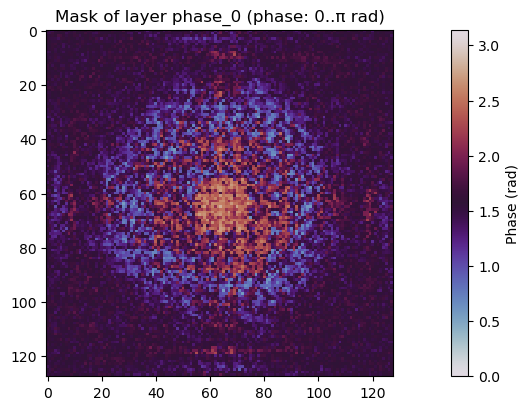

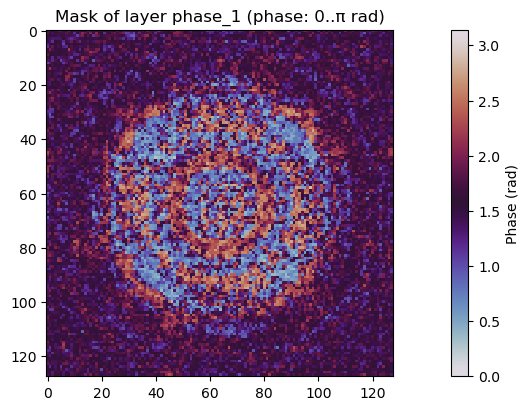

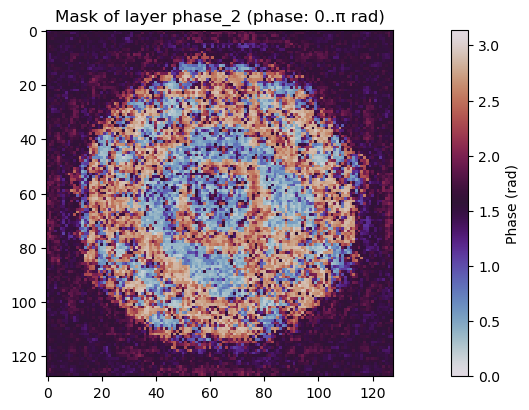

In [49]:
mask_visualiztion()

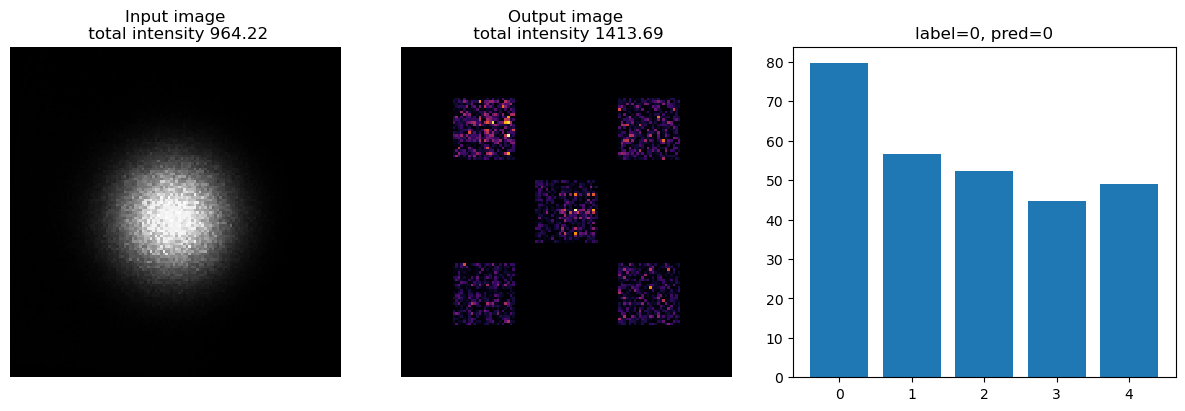

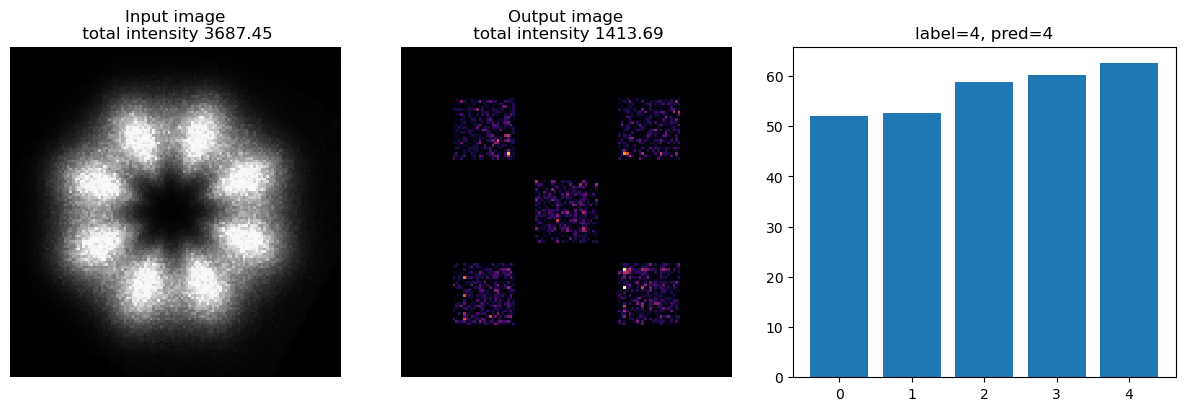

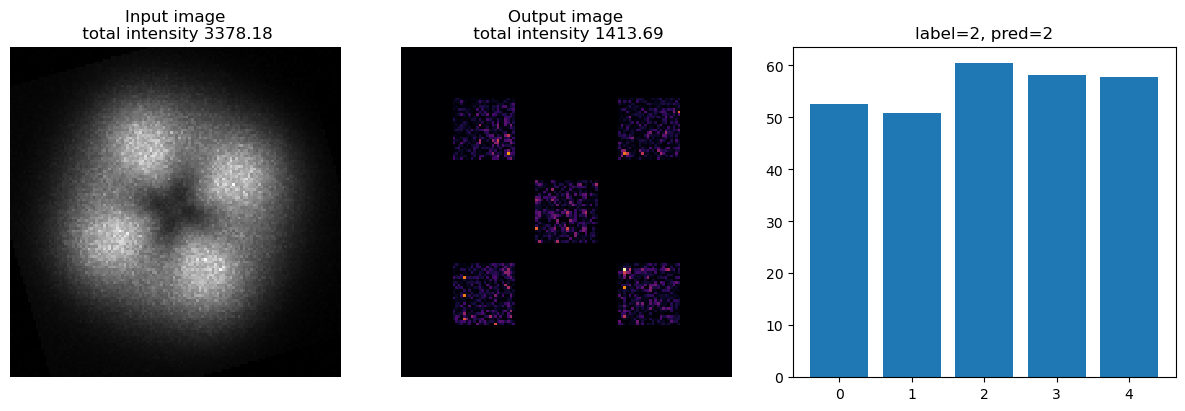

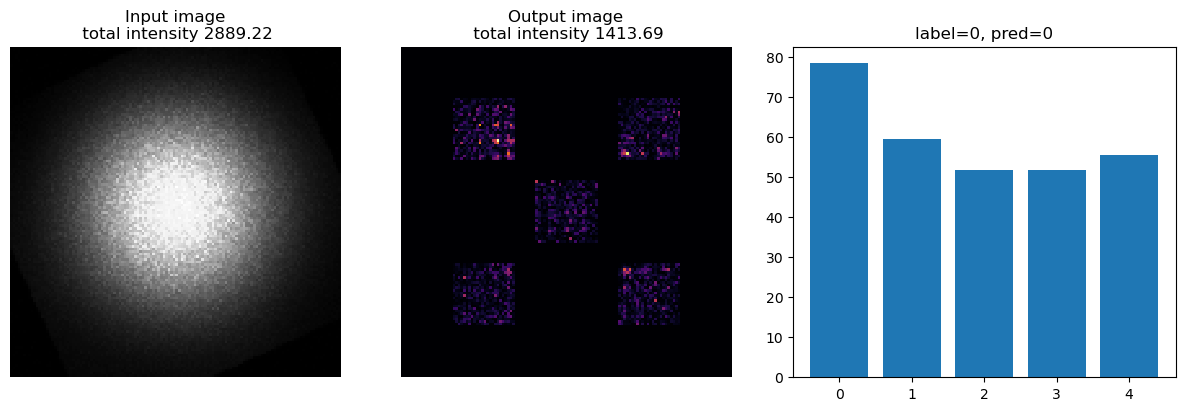

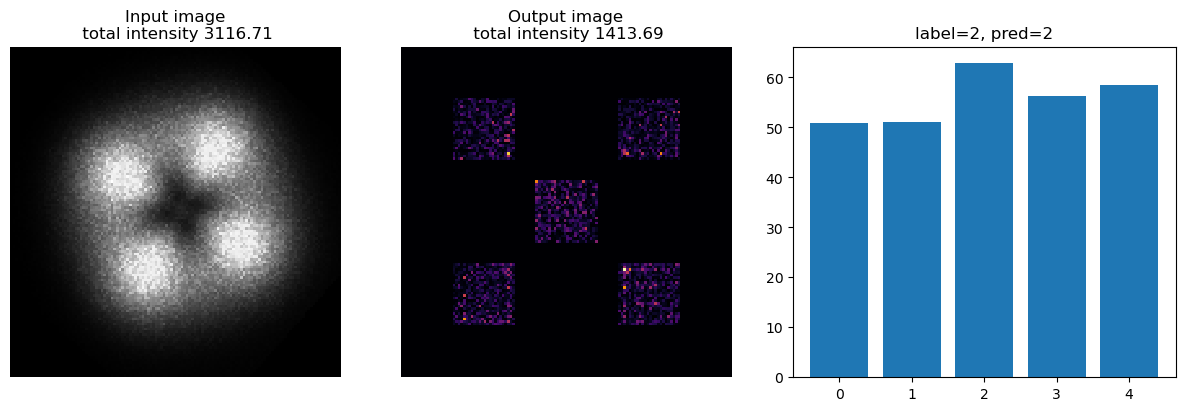

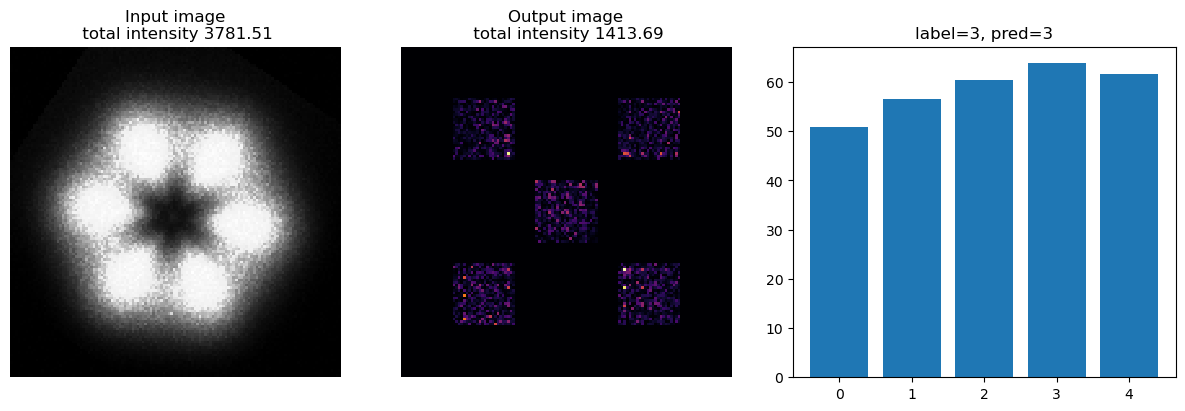

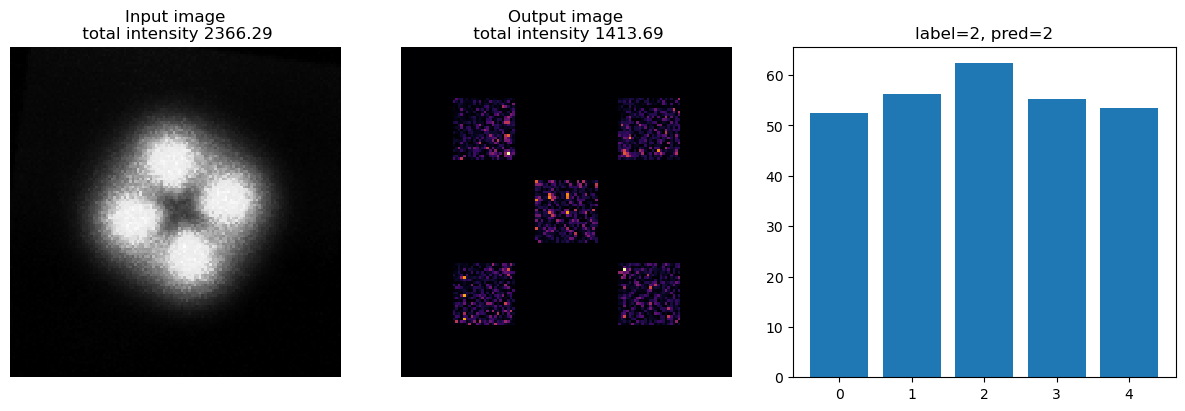

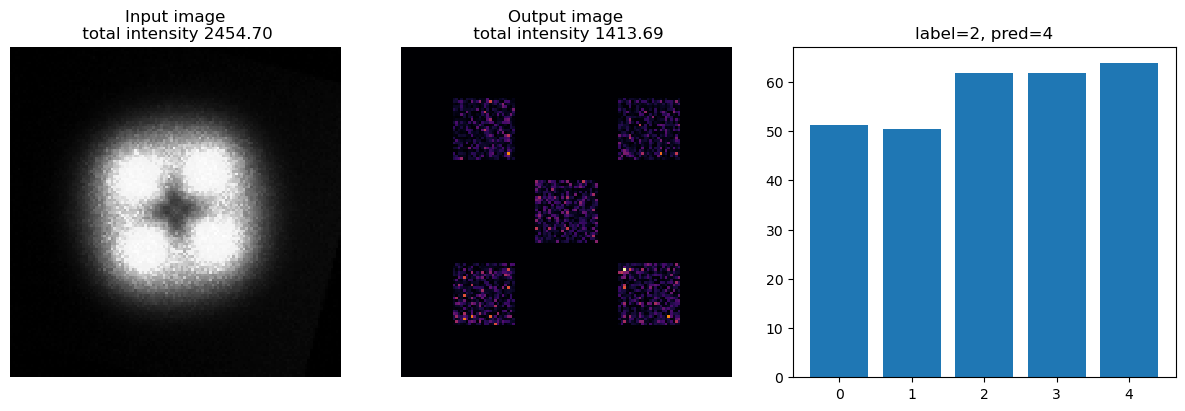

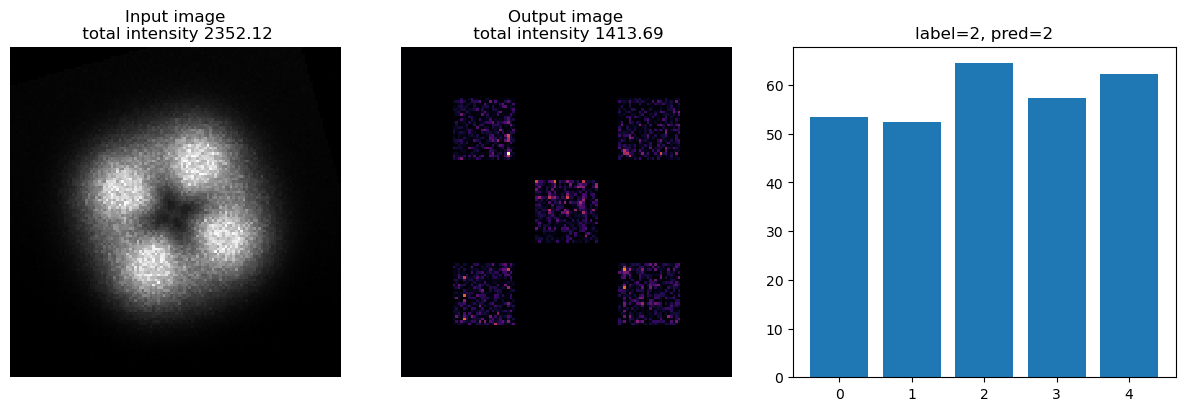

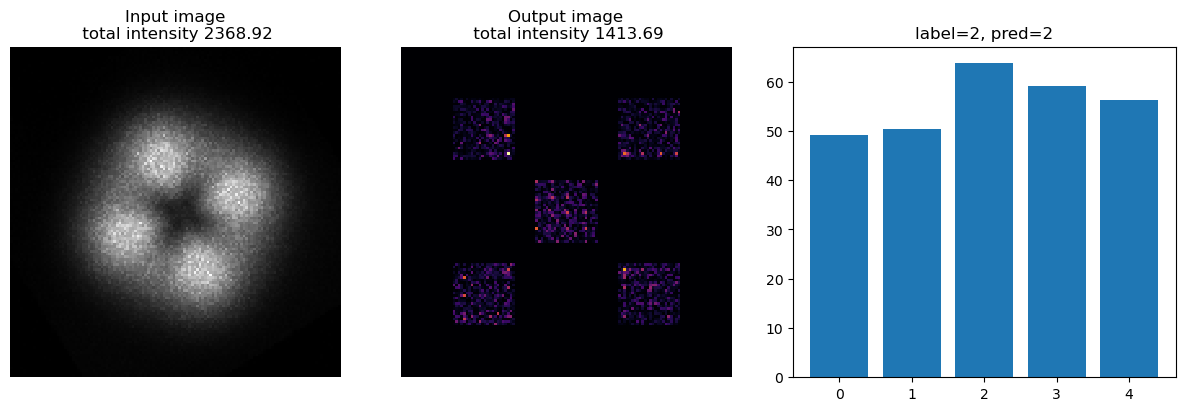

In [50]:
rand_ind = np.random.choice(range(len(val_dataset)), size=10, replace=False)
for ind in rand_ind:
    visualize(val_dataset[ind][0], val_dataset[ind][1])

Saved height_map to: E:\pycharm file\D2NN-with-Pytorch\height_map.npy
  shape=(3, 128, 128), dtype=float32, unit=m
  min=0.0, max=6.765999387425836e-07
distance_0 = 3.9969 mm
distance_1 = 4.0002 mm
distance_2 = 3.9999 mm
distance_3 = 3.9988 mm
distance_4 = 5.0014 mm
已保存 trained_distances.npy


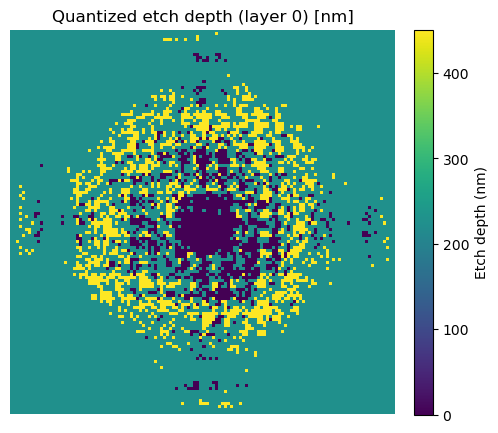

Etch depth levels (nm) and pixel counts:
  期望值: 0, 173, 346, 676.6 nm
  0 nm: 1302 pixels
  226 nm: 13400 pixels
  451 nm: 1682 pixels


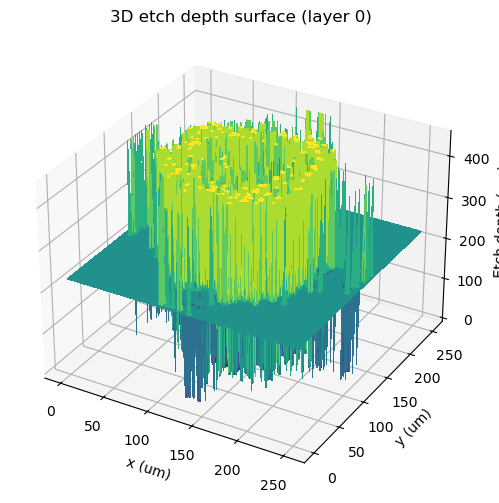

In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ---------------------- 可改参数 ----------------------
layer_index = 0          # 想看第几层：0,1,2,...
pixel_size_um = 2.0      # 像素尺寸（um），例如 2e-6 m -> 2.0 um

# 导出参数
save_height_map = True
height_map_filename = "height_map.npy"   # 将保存到当前工作目录
save_unit = "m"  # "m" 或 "nm"；建议 "m" 以直接用于 Lumerical
# -----------------------------------------------------


def _get_project_dir() -> str:
    try:
        return os.path.dirname(os.path.abspath(__file__))
    except NameError:
        return os.getcwd()


def _collect_all_layer_etch_depths(model) -> np.ndarray:
    """
    从 model.named_parameters() 中收集 phase_0, phase_1, ... 的刻蚀深度图。

    流程: 裸参数 → π×sigmoid → 连续相位 → 4级量化 → Fig.S1 刻蚀深度

    返回：etch_depth_map, shape = [num_layer, N, N], dtype=float32
          单位：nm（内部计算用nm，保存时再转换）
    """
    params = dict(model.named_parameters())
    phase_keys = [k for k in params.keys() if k.startswith("phase_")]

    def _idx(k: str) -> int:
        return int(k.split("_", 1)[1])

    phase_keys = sorted(phase_keys, key=_idx)
    if not phase_keys:
        raise ValueError("在 model.named_parameters() 中未找到形如 phase_0 的参数。")

    etch_depths = []
    for k in phase_keys:
        # ① 取出裸参数
        raw_param = params[k].detach().cpu()

        # ② 还原 forward 中的相位计算: φ = π × sigmoid(param)
        phi_continuous = np.pi * torch.sigmoid(raw_param)  # (0, π)

        # ③ 量化为 4 级: {0, π/4, π/2, 3π/4}
        phi_quantized = quantize_phase_16level(phi_continuous)

        # ④ 转换为刻蚀深度（米）
        etch_m = phase_to_etch_depth(phi_quantized.numpy())  # [N,N] 单位: m

        # 转为 nm 存储
        etch_nm = (etch_m * 1e9).astype(np.float32)  # [N,N] 单位: nm
        etch_depths.append(etch_nm)

    etch_depth_map_nm = np.stack(etch_depths, axis=0)  # [L,N,N]
    return etch_depth_map_nm


# 1) 生成全层刻蚀深度图（nm）
etch_depth_map_nm = _collect_all_layer_etch_depths(model)

# 2) 保存为 .npy
if save_height_map:
    project_dir = _get_project_dir()
    out_path = os.path.join(project_dir, height_map_filename)

    if save_unit == "m":
        height_map_to_save = (etch_depth_map_nm * 1e-9).astype(np.float32)  # nm -> m
    elif save_unit == "nm":
        height_map_to_save = etch_depth_map_nm.astype(np.float32)
    else:
        raise ValueError("save_unit 只能是 'm' 或 'nm'。")

    np.save(out_path, height_map_to_save)
    print(f"Saved height_map to: {out_path}")
    print(f"  shape={height_map_to_save.shape}, dtype={height_map_to_save.dtype}, unit={save_unit}")
    print(f"  min={float(height_map_to_save.min())}, max={float(height_map_to_save.max())}")

# 3) 同时导出训练好的距离参数
distances = []
num_layers = etch_depth_map_nm.shape[0]
for i in range(num_layers + 2):
    d = getattr(model, f"distance_{i}").detach().cpu().item()
    distances.append(d)
    print(f"distance_{i} = {d*1e3:.4f} mm")
np.save(os.path.join(_get_project_dir(), "trained_distances.npy"), np.array(distances))
print("已保存 trained_distances.npy")

# 4) 取出想看的那一层，用于 2D/3D 可视化（nm）
if not (0 <= layer_index < etch_depth_map_nm.shape[0]):
    raise IndexError(f"layer_index={layer_index} 超出范围 0..{etch_depth_map_nm.shape[0]-1}")

H = etch_depth_map_nm[layer_index]  # [N,N] nm

# 2D 刻蚀深度热力图
plt.figure(figsize=(6, 5))
im = plt.imshow(H, cmap="viridis", origin="upper")
plt.title(f"Quantized etch depth (layer {layer_index}) [nm]")
plt.axis("off")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Etch depth (nm)")
plt.show()

# 刻蚀深度台阶统计
vals, counts = np.unique(np.round(H).astype(int), return_counts=True)
print("Etch depth levels (nm) and pixel counts:")
print("  期望值: 0, 173, 346, 676.6 nm")
for v, c in zip(vals, counts):
    print(f"  {v} nm: {c} pixels")

# 3D 曲面图
Ny, Nx = H.shape
x = np.arange(Nx, dtype=np.float32) * float(pixel_size_um)
y = np.arange(Ny, dtype=np.float32) * float(pixel_size_um)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, H, rstride=1, cstride=1, cmap="viridis", linewidth=0, antialiased=False)
ax.set_title(f"3D etch depth surface (layer {layer_index})")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_zlabel("Etch depth (nm)")
plt.show()

Confusion matrix (rows=predicted, cols=true):
[[1126   21   11    6    9]
 [  37 1096   37   21    6]
 [  19   59 1010  109   39]
 [   5   19   97  901  157]
 [  13    5   45  163  989]]
每种标签总个数： [1200, 1200, 1200, 1200, 1200]
每种标签预测正确的个数： [1126, 1096, 1010, 901, 989]
每种标签的识别准确率为(%): ['93.8', '91.3', '84.2', '75.1', '82.4']


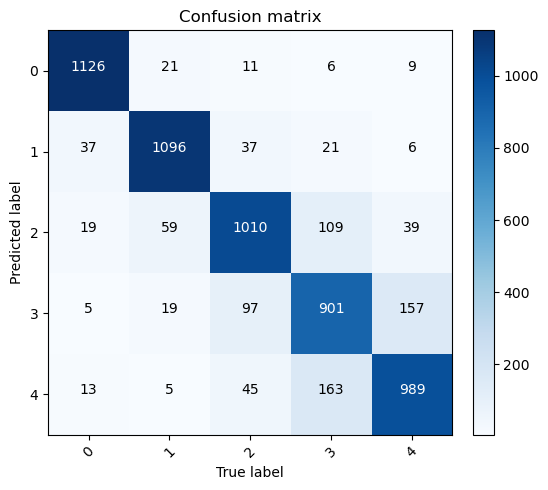

In [52]:
# 安全且稳健的混淆矩阵生成与绘制
def update_confusion_matrix(conf_matrix, predicted, labels):
    """
    conf_matrix: torch.Tensor (CPU, integer) shape [C, C]
    predicted: 1D torch Tensor on CPU (predicted labels)
    labels: 1D torch Tensor on CPU (true labels)
    """
    # 转为 Python 列表进行安全索引（也可用张量索引，但此处简单明了）
    pred_list = predicted.tolist()
    label_list = labels.tolist()
    for p, t in zip(pred_list, label_list):
        conf_matrix[p, t] += 1
    return conf_matrix

# 1) 初始化混淆矩阵（在 CPU 上，整数类型）
conf_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)  # [pred, true]

# 2) 遍历验证集并更新混淆矩阵
with torch.no_grad():
    for i, (images, labels) in enumerate(val_dataloader):
        images = images.to(device)
        images = torch.sqrt(torch.squeeze(images))
        labels = labels.to(device)

        out_labels, out_images = model(images)             # out_labels: logits 或概率 [B, C]
        _, predicted = torch.max(out_labels.data, 1)      # predicted on device

        # 把 predicted 和 labels 转回 CPU 再更新矩阵
        predicted_cpu = predicted.cpu()
        labels_cpu = labels.cpu()

        conf_matrix = update_confusion_matrix(conf_matrix, predicted_cpu, labels_cpu)

# 3) 显示 / 分析混淆矩阵
import numpy as np
cm = conf_matrix.numpy()  # 转为 numpy 方便显示与计算

print("Confusion matrix (rows=predicted, cols=true):")
print(cm)

# 每类的样本数（真实标签统计）
per_class_counts = cm.sum(axis=0)  # 按列求和 -> 每个真实类的样本总数
corrects = np.diag(cm)
per_class_accuracy = (corrects / (per_class_counts + 1e-12)) * 100.0  # 百分比，避免除零

print("每种标签总个数：", per_class_counts.tolist())
print("每种标签预测正确的个数：", corrects.tolist())
print("每种标签的识别准确率为(%):", ["{:.1f}".format(x) for x in per_class_accuracy.tolist()])

# 4) 可视化（matplotlib）
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar(im, fraction=0.046, pad=0.04)

# x/y ticks: true classes (cols) / predicted classes (rows)
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes), rotation=45)
plt.yticks(tick_marks, range(num_classes))

# 在格子里写数值
thresh = cm.max() / 2.0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel('Predicted label')
plt.xlabel('True label')
plt.tight_layout()
plt.show()

In [53]:
# 将模型中的phase导出来
phase_params_dump = []
for param in model.named_parameters():
    phase_params_dump.append(param[1])

In [54]:
phase[0].shape

torch.Size([128, 128])